# PARTE A - MLP per regressione (dataset diabetes)

## ATTIVITÀ 1.1 - CARICAMENTO E SPLIT

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, random_state=42)

print(f"Shape features: {diabetes.data.shape}")
print(f"train: {X_train.shape[0]} campioni | test: {X_test.shape[0]} campioni")

Shape features: (442, 10)
train: 331 campioni | test: 111 campioni


### ATTIVITÀ 1.2 - BASELINE LINEARE

In [9]:
lr = make_pipeline(StandardScaler(), LinearRegression())
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mse_lr = np.mean((y_pred_lr - y_test)**2)

print(f"train : {lr.score(X_train, y_train):.4f}")
print(f"test  : {lr.score(X_test,  y_test):.4f}")
print(f"MSE test : {mse_lr:.2f}")


train : 0.5190
test  : 0.4849
MSE test : 2848.31


### ATTIVITÀ 1.3 - MLPRegressor

In [27]:
mlp = make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64, 64), 
activation='relu', solver='adam', max_iter=500, random_state=42))

t0 = time.time()
mlp.fit(X_train, y_train)
elapsed = time.time() - t0

y_pred_mlp = mlp.predict(X_test)
mse_mlp = np.mean((y_pred_mlp - y_test)**2)

print(f"train : {mlp.score(X_train, y_train):.4f}")
print(f"test  : {mlp.score(X_test,  y_test):.4f}")
print(f"MSE test : {mse_mlp:.2f}")
print(f"tempo: {elapsed:.3f}s,  iterazioni: {mlp[-1].n_iter_}")

train : 0.9995
test  : 0.8358
MSE test : 1.35
tempo: 21.267s,  iterazioni: 305


### ATTIVITÀ 1.4 - ESPERIMENTI GUIDATI

#### CASO 1: (32,), RELU

In [60]:
m = make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(32,), 
activation='relu', solver='adam', max_iter=500, random_state=42))
m.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=(32,), max_iter=1500,
                              random_state=42))])

#### CASO 2: (64,64), relu

In [62]:
m = make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(64, 64), 
activation='relu', solver='adam', max_iter=500, random_state=42))
m.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500,
                              random_state=42))])

#### CASO 3: (128,64), relu

In [ ]:
m = make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(128, 64), 
activation='relu',solver='adam', max_iter=500, random_state=42))
m.fit(X_train, y_train)

#### CASO 4: (64,64), tanh

In [ ]:
m = make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(64, 64), 
activation='tanh', solver='adam', max_iter=500, random_state=42))
m.fit(X_train, y_train)

#### CASO 5: (128,64), relu, early_stopping

In [75]:
m = make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(128, 64),
activation='relu', solver='adam', max_iter=500, early_stopping=True, random_state=42))
m.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(128, 64),
                              max_iter=500, random_state=42))])

#### Risultati

In [73]:
mse = np.mean((m.predict(X_test) - y_test)**2)
print(f"R2 Train : {m.score(X_train, y_train):.4f}")
print(f"R2 Test  : {m.score(X_test,  y_test):.4f}")
print(f"MSE Test : {mse:.2f}")

R2 Train : 0.9987
R2 Test  : 0.8247
MSE Test : 1.44


### ATTIVITÀ 1.5 - DOMANDE

- Come cambia l'errore di test al crescere della complessità del modello?
    Passando da (32,) a (64,64) fino a (128,64), il $R^2$ sul training tende a salire perché la rete ha più parametri e riesce ad adattarsi meglio ai dati di training. Sul test invece il miglioramento non sempre segue lo stesso andamento infatti, una rete più grande non garantisce un errore di test più basso, perché rischia di memorizzare i dati invece di generalizzarli.

- Notate overfitting?
        Sì: confrontando ${R^2}$_train e ${R^2}$_test nei casi più complessi si nota un gap crescente tra i due valori segno che il modello performa bene sul training ma peggiora sul test.

- Il tempo di addestramento varia in modo sensibile al crescere della rete?
    Su un dataset piccolo come diabetes le differenze non sono molte. Una rete più grande ha più parametri da aggiornare a ogni iterazione e quindi impiega più tempo. Il caso 6 con early_stopping può terminare prima delle 500 iterazioni se il modello smette di migliorare, riducendo il tempo totale di addestramento.

# Parte B – MLP per classificazione multiclasse (digits o wine)

1. **Caricamento e split**
    * Dataset:
        * load_digits (10 classi, immagini 8x8) oppure load_wine (3 classi).
    * Split train/test come prima.

In [55]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    digits.data, digits.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)


2. **Baseline di classificazione**
* Addestrare una LogisticRegression(multi_class="multinomial",
  solver="lbfgs") come riferimento.

In [57]:
from sklearn.linear_model import LogisticRegression

pipeline = make_pipeline(LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=10000))
pipeline.fit(X_train, y_train)
print(f"Accuracy Train (LogisticRegression): {pipeline.score(X_train, y_train):.4f}")
print(f"Accuracy Test (LogisticRegression): {pipeline.score(X_test,  y_test):.4f}")

Accuracy Train (LogisticRegression): 1.0000
Accuracy Test (LogisticRegression): 0.9722


3. **MLPClassifier**
* Addestrare un MLPClassifier:
    * Es: hidden_layer_sizes=(64,), activation="relu", solver="adam", max_iter=300, random_state=42.
    * Verificare che:
        * MLPClassifier usa cross-entropy per la classificazione (log_loss / cross-entropy è la loss implicita).
        * Le probabilità sono ottenute via softmax sul layer di output.

In [58]:
from sklearn.metrics import log_loss

clf = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,),
activation='relu',solver='adam', max_iter=300, random_state=42))
clf.fit(X_train, y_train)

print(f"Accuracy Train (MLPClassifier): {clf.score(X_train, y_train):.4f}")
print(f"Accuracy Test (MLPClassifier): {clf.score(X_test,  y_test):.4f}")
print(f"out_activation: {clf[-1].out_activation_}")
print(f"Loss: {clf[-1].loss_}")

Accuracy Train (MLPClassifier): 1.0000
Accuracy Test (MLPClassifier): 0.9778
out_activation: softmax
Loss: 0.005785636962272484


4. **Analisi delle probabilità**
Attività concreta:
* Far predire su alcune istanze di test:
    * y_pred = clf.predict(X_test)
    * proba = clf.predict_proba(X_test)
* Far guardare una riga di proba[i] e chiedere:
    * qual è il logit (concetto teorico) vs probabilità,
    * interpretare probabilità alte/basse.

In [76]:
y_pred = clf.predict(X_test)
proba  = clf.predict_proba(X_test)

i = 1
print(f"Classe reale: {y_test[i]}")
print(f"Classe predetta: {y_pred[i]}")
print(f"Probabilità: {proba[i].round(2)}")
print(f"Probabilità più alta: {proba[i].max():.4f}")
print(f"Somma probabilità: {proba[i].sum():.6f}. Deve essere 1 per la softmax")

Classe reale: 9
Classe predetta: 9
Probabilità: [0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.99]
Probabilità più alta: 0.9893
Somma probabilità: 1.000000. Deve essere 1 per la softmax


I logit rappresentano i punteggi grezzi mentre la probabiltà sono i punteggi normalizzati. La probabiltà più alta indica che il modello è fiducioso, quindi l'errore sarà molto basso, mentre la probabilità più bassa indica che il modello ha subito un errore; di conseguenza la loss sarà alta.

5. **Calcolare a mano la cross-entropy di una singola istanza usando NumPy, confrontando con log_loss di scikit-learn**

In [78]:
from sklearn.metrics import log_loss
import numpy as np

i = 1
p_classe_vera = proba[i][y_test[i]]

ce_mano   = -np.log(p_classe_vera)
ce_sklearn = log_loss([y_test[i]], [proba[i]], labels=list(range(10)))

print(f"Cross-entropy manuale: {ce_mano:.6f}")
print(f"Cross-entropy sklearn log_loss: {ce_sklearn:.6f}")

Cross-entropy manuale: 0.010781
Cross-entropy sklearn log_loss: 0.010781


Come si può notare il risultato è lo stesso, sia cross-entropy calcolata a mano che la funzione log_loss di sklearn danno 0.010781.

6. **Softmax e cross-entropy – parte esplicita**
Inserire nel notebook una breve funzione:
* softmax(z) (con trucco di stabilità: sottrarre z.max()),
* cross_entropy(y_true_one_hot, y_pred_proba).

In [80]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()

def cross_entropy(y_one_hot, y_proba):
    return -np.sum(y_one_hot * np.log(y_proba + 1e-15))

z_test = np.array([1.0, 2.0, 0.1])
p_test = softmax(z_test)
y_oh = np.array([0, 0, 1])
ce_test = cross_entropy(y_oh, p_test)

print(f"Logits: {z_test}")
print(f"Softmax: {p_test.round(4)}")
print(f"Cross-entropy: {ce_test:.6f}")

Logits: [1.  2.  0.1]
Softmax: [0.2424 0.659  0.0986]
Cross-entropy: 2.317030


7. **Esercizio mirato**:
* Prendere i logits dal penultimo step (se non disponibile, simulare un vettore di logits)
* applicare softmax e poi la cross-entropy per una label one-hot

In [82]:
np.random.seed(42)
classe_reale = 2
y_one_hot = np.zeros(len(z_test))
y_one_hot[classe_reale] = 1

p_sim = softmax(z_test)
loss = cross_entropy(y_one_hot, p_sim)

print(f"Logits z: {z_test}")
print(f"Classe reale: {classe_reale}")
print(f"One_hot: {y_one_hot}")
print(f"Softmax p: {p_sim}")
print(f"Cross-entropy loss: {loss:.6f}")

Logits z: [1.  2.  0.1]
Classe reale: 2
One_hot: [0. 0. 1.]
Softmax p: [0.24243297 0.65900114 0.09856589]
Cross-entropy loss: 2.317030


Dalla scelta della classe reale (2), si può notare che la loss è alta perché la probabilità della classe reale è molto bassa ed è il caso in cui il modello sbaglia.

# PARTE C - Mini-esperimento su overfitting e loss

### Caricamento dataset e addestramento

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors 
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Allenamento delle due reti

In [3]:
mlp_small = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=42)
mlp_small.fit(X_train_scaled, y_train)

mlp_large = MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=500, random_state=42)
mlp_large.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=500, random_state=42)

### Confronto accuracy train/test

In [4]:
acc_train_small = accuracy_score(y_train, mlp_small.predict(X_train_scaled))
acc_test_small = accuracy_score(y_test, mlp_small.predict(X_test_scaled))

acc_train_large = accuracy_score(y_train, mlp_large.predict(X_train_scaled))
acc_test_large = accuracy_score(y_test, mlp_large.predict(X_test_scaled))

print("Risultati MLP Piccolo (32,)")
print(f"Accuracy su Train: {acc_train_small:.4f}")
print(f"Accuracy su Test:  {acc_test_small:.4f}")

print("\nRisultati MLP Grande (256, 256)")
print(f"Accuracy su Train: {acc_train_large:.4f}")
print(f"Accuracy su Test:  {acc_test_large:.4f}")

Risultati MLP Piccolo (32,)
Accuracy su Train: 1.0000
Accuracy su Test:  0.9806

Risultati MLP Grande (256, 256)
Accuracy su Train: 1.0000
Accuracy su Test:  0.9833


### Rappresentazione grafica

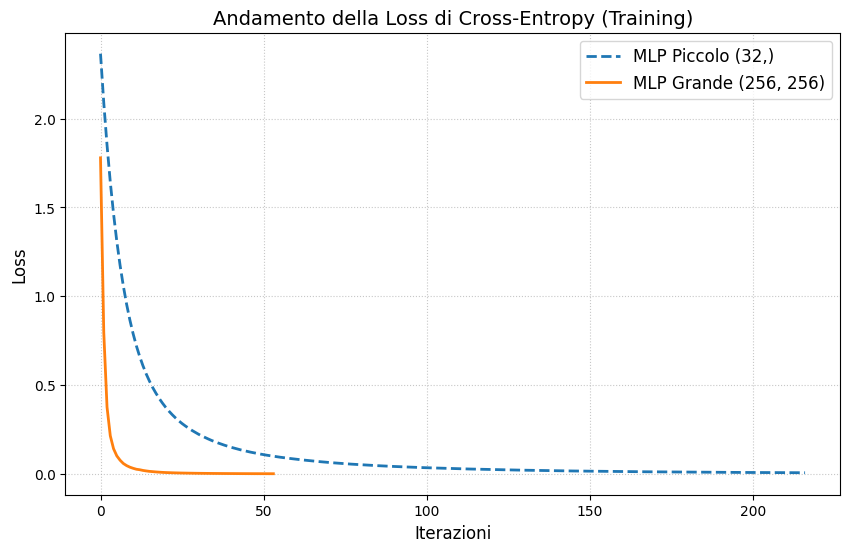

In [6]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(10, 6))

plt.plot(mlp_small.loss_curve_, label='MLP Piccolo (32,)', linestyle='--', linewidth=2)
plt.plot(mlp_large.loss_curve_, label='MLP Grande (256, 256)', linewidth=2)

plt.title("Andamento della Loss di Cross-Entropy (Training)", fontsize=14)
plt.xlabel("Iterazioni", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

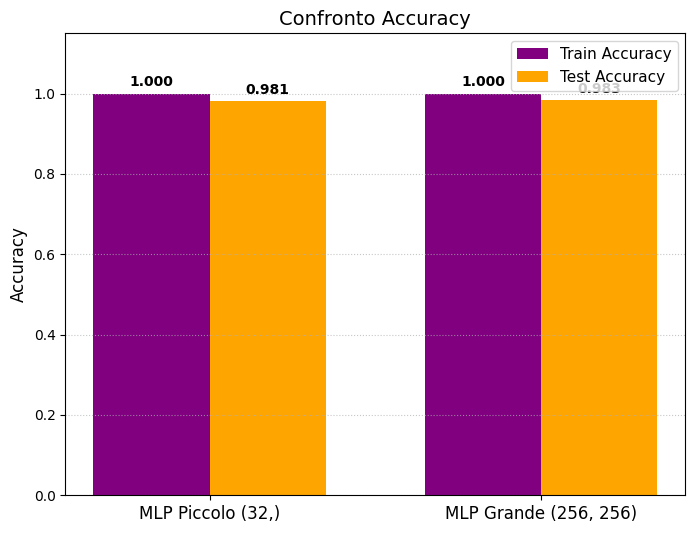

In [32]:
import numpy as np

labels = ['MLP Piccolo (32,)', 'MLP Grande (256, 256)']
train_accuracies = [acc_train_small, acc_train_large]
test_accuracies = [acc_test_small, acc_test_large]

x = np.arange(len(labels))
width = 0.35                

fig, ax = plt.subplots(figsize=(8, 6))

barre_train = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='purple')
barre_test = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='orange')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Confronto Accuracy', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.7)

ax.bar_label(barre_train, padding=3, fmt='%.3f', fontsize=10, fontweight='bold')
ax.bar_label(barre_test, padding=3, fmt='%.3f', fontsize=10, fontweight='bold')

plt.show()

### DOMANDE

- La loss di training converge? Ci sono oscillazioni?
    La loss di training converge costantemente. Si può notare dal grafico che entrambe le curve scendono e tendono ad appiattirsi. In particolare, l'MLP "grande" converge in modo molto più ripido e veloce, portando la loss a valori vicinissimi allo zero in poche iterazioni. Per quanto riguarda le oscillazioni, se si utilizza l'ottimizzatore di default per questo tipo di dati (ADAM - Adaptive Moment Estimation), la discesa è generalmente molto fluida e le oscillazioni sono minime o del tutto assenti. Forti oscillazioni si vedrebbero solo impostando un learning rate troppo alto o utilizzando mini-batch estremamente piccoli con una discesa del gradiente stocastica pura.

- Il modello più grande ha maggiore rischio di overfitting?
    Sì, il rischio è maggiore. Il modello "grande" (256, 256) possiede una quantità di parametri (pesi e bias) superiore rispetto al modello "piccolo" (32,). Questo gli consente di imparare a memoria le peculiarità e i rumori del dataset di training. Di conseguenza, il modello grande raggiungerà un'accuracy perfetta (o quasi) sui dati di train, ma guardando l'accuracy sul test set si può notare un divario (generalization gap) netto. Il modello piccolo, avendo meno parametri, è un po' più rigido ed è "costretto" a generalizzare estraendo solo i pattern principali, difendendosi meglio dall'overfitting.

- Che legame vedete tra cross-entropy che scende e accuracy che sale?
    La cross-entropy è una metrica continua e differenziabile che misura l'incertezza. Quando scende, significa che il modello sta assegnando probabilità matematiche sempre più alte e "sicure" alla classe corretta. L'accuracy è una metrica discreta che misura semplicemente se la classe scelta, cioè quella con la probabilità più alta, è quella giusta o meno. Poiché la rete neurale non può ottimizzare direttamente l'accuracy, ottimizza la cross-entropy. Abbassando l'incertezza probabilistica (loss che scende), le probabilità per la classe corretta aumentano fino a diventare le più alte, passando così nella predizione corretta (accuracy che sale).

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5700d1a3-48c2-45d9-a672-84b755126fc8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>